# 1.3 Add time: the energy balance model

The same physics as Chapter 1.2, now as a differential equation for a planet with heat
capacity $C$ (an ocean mixed layer roughly 100 m deep):

$$C \frac{dT}{dt} = \frac{S_0}{4}\bigl(1-\alpha(T)\bigr) - \varepsilon \sigma T^4 .$$

One addition carries all the new physics: the albedo now *depends on temperature*. A
cold planet grows ice and reflects more sunlight, cooling it further — the ice–albedo
feedback. This chapter introduces the pattern every later model uses (a pure single-step
function rolled out with `lax.scan`) and takes the first gradient *through* a time
integration. Because this system is stable, the gradient is perfectly behaved. That
good behavior is a property of the physics, not of the method — Part 3 begins where it
fails.

```{admonition} Learning goals
:class: tip
- Structure a time-stepping model as a pure step function plus a `lax.scan` rollout
- Differentiate through a rollout and verify against a finite difference
- Find the model's two stable climates and its hysteresis loop
- Observe how the gradient behaves near a tipping point — and what it cannot see
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

## The model

Ice cover responds to temperature through a smooth ramp between a warm, dark planet
($\alpha = 0.28$) and an ice-covered, bright one ($\alpha = 0.62$), centered at 263 K:

In [2]:
S0 = 1361.0            # solar constant, W m^-2
sigma = 5.67e-8        # Stefan-Boltzmann constant, W m^-2 K^-4
emissivity = 0.61
C = 4.0e8              # heat capacity, J m^-2 K^-1 (~100 m of ocean)

def albedo(T):
    return 0.28 + (0.62 - 0.28) * 0.5 * (1.0 - jnp.tanh((T - 263.0) / 5.0))

def energy_imbalance(T, S=S0, eps=emissivity):
    """Net downward energy flux at the surface, W m^-2."""
    return S * (1.0 - albedo(T)) / 4.0 - eps * sigma * T**4

## Rollout with `lax.scan`

A single time step is a pure function from temperature to temperature (forward Euler,
one-month steps — short enough for this smooth system). `lax.scan` repeats it,
returning both the final state and the full trajectory:

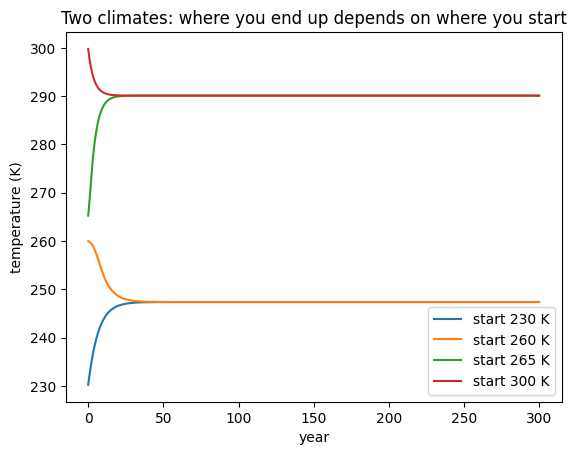

In [3]:
dt = 86400.0 * 30            # one month, seconds

def step(T, _):
    T_new = T + dt / C * energy_imbalance(T)
    return T_new, T_new      # (carry for the next step, value to record)

def integrate(T0, n_years=300):
    T_final, trajectory = jax.lax.scan(step, T0, None, length=n_years * 12)
    return T_final, trajectory

years = jnp.arange(300 * 12) / 12.0
for T0 in [230.0, 260.0, 265.0, 300.0]:
    _, traj = integrate(jnp.float64(T0))
    plt.plot(years, traj, label=f"start {T0:.0f} K")
plt.xlabel("year"); plt.ylabel("temperature (K)")
plt.legend(); plt.title("Two climates: where you end up depends on where you start")
plt.show()

Trajectories starting below about 263 K fall to a frozen equilibrium near 247 K;
warmer starts converge to a temperate climate near 290 K. The two stable states, and
the unstable boundary between them, are visible directly in the energy imbalance —
the three temperatures where absorbed and emitted radiation balance:

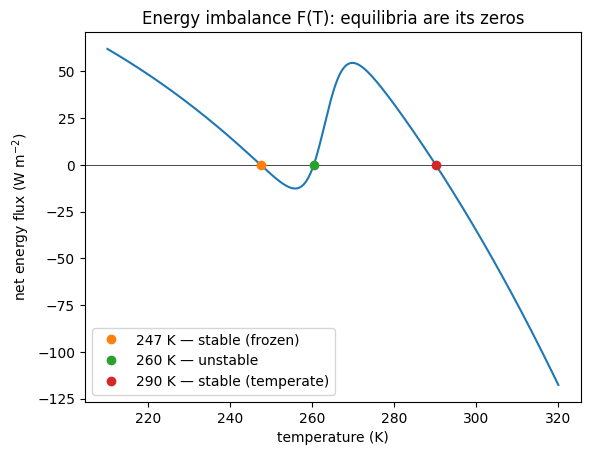

In [4]:
T_range = jnp.linspace(210.0, 320.0, 500)
F = jax.vmap(energy_imbalance)(T_range)
plt.axhline(0, color="k", lw=0.5)
plt.plot(T_range, F)
for T_eq, kind in [(247.4, "stable (frozen)"), (260.3, "unstable"), (290.1, "stable (temperate)")]:
    plt.plot(T_eq, 0, "o", label=f"{T_eq:.0f} K — {kind}")
plt.xlabel("temperature (K)"); plt.ylabel("net energy flux (W m$^{-2}$)")
plt.legend(); plt.title("Energy imbalance F(T): equilibria are its zeros")
plt.show()

## Gradient through the rollout

Nothing new is needed to differentiate the time-stepped model: `grad` traces through
all 3,600 steps of the `scan` and applies the chain rule end to end. Here is the
sensitivity of the final temperature to the emissivity — physically, to the strength of
the greenhouse effect (lower emissivity = stronger greenhouse):

In [5]:
def final_T(eps):
    def step_eps(T, _):
        T_new = T + dt / C * energy_imbalance(T, eps=eps)
        return T_new, None
    T, _ = jax.lax.scan(step_eps, 288.0, None, length=300 * 12)
    return T

g = jax.grad(final_T)(0.61)
fd = (final_T(0.61 + 1e-6) - final_T(0.61 - 1e-6)) / 2e-6
print(f"d(equilibrium T)/d(emissivity): autodiff {g:.4f} K, finite difference {fd:.4f} K")

d(equilibrium T)/d(emissivity): autodiff -118.9269 K, finite difference -118.9269 K


Multiplying by a 1% emissivity change (0.0061) converts this to roughly a kelvin of
warming — the model's greenhouse sensitivity, from one reverse pass. The check
against a finite difference agrees to many digits, as it should for this smooth,
stable model.

## Hysteresis: the climate remembers

Because two stable climates coexist, slowly varying the solar constant $S$ traces
different paths on the way down and on the way up — the frozen state persists far past
the point where it formed. Each point below is a 400-year equilibrium started from the
end state of the previous one:

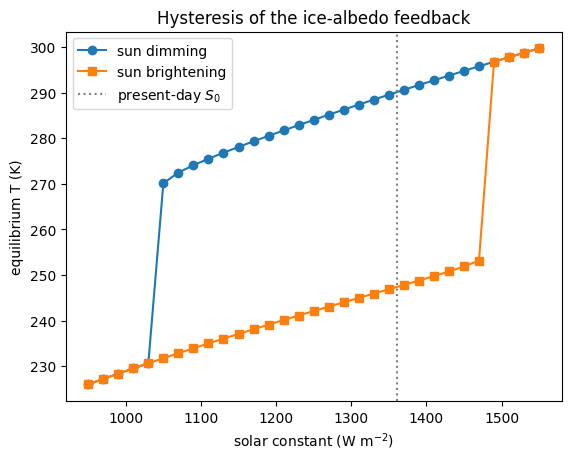

In [6]:
def equilibrium(S, T0, n_years=400):
    def step_S(T, _):
        return T + dt / C * energy_imbalance(T, S=S), None
    T, _ = jax.lax.scan(step_S, T0, None, length=n_years * 12)
    return T

S_values = jnp.linspace(950.0, 1550.0, 31)
T = jnp.float64(300.0)
cooling_path = []
for S in S_values[::-1]:                      # dim the sun
    T = equilibrium(S, T); cooling_path.append(T)
warming_path = []
for S in S_values:                            # brighten it again
    T = equilibrium(S, T); warming_path.append(T)

plt.plot(S_values[::-1], jnp.stack(cooling_path), "o-", label="sun dimming")
plt.plot(S_values, jnp.stack(warming_path), "s-", label="sun brightening")
plt.axvline(1361, color="gray", ls=":", label="present-day $S_0$")
plt.xlabel("solar constant (W m$^{-2}$)"); plt.ylabel("equilibrium T (K)")
plt.legend(); plt.title("Hysteresis of the ice-albedo feedback")
plt.show()

The warm climate collapses near $S \approx 1045$ W m⁻²; the frozen climate does not
thaw until $S \approx 1490$. Between those values the climate depends on its history —
the signature of a system with multiple equilibria, familiar from Snowball Earth
hypotheses.

## What the gradient sees near a tipping point

Now differentiate the equilibrium temperature with respect to the solar constant at
points approaching the collapse. The sensitivity grows as the stable state weakens — an
early-warning signal — but notice what happens *at* the transition:

In [7]:
T = jnp.float64(300.0)
print("   S        T_eq      dT_eq/dS")
for S in [1200.0, 1100.0, 1060.0, 1050.0, 1046.0]:
    T = equilibrium(jnp.float64(S), T)                       # walk down the warm branch
    g = jax.grad(equilibrium)(jnp.float64(S), T)
    print(f"{S:7.1f}  {float(T):8.2f}  {float(g):9.4f}  K per W m^-2")

   S        T_eq      dT_eq/dS
 1200.0    281.09     0.0591  K per W m^-2
 1100.0    274.78     0.0706  K per W m^-2
 1060.0    271.48     0.1086  K per W m^-2


 1050.0    270.09     0.2045  K per W m^-2
 1046.0    231.52     0.0553  K per W m^-2


Read the table carefully — it tells the story in two acts. The sensitivity roughly
quadruples between $S = 1200$ and $S = 1050$ as the warm equilibrium loses stability:
the divergence of $dT/dS$ is the mathematical fingerprint of an approaching fold
bifurcation, and the basis of proposed early-warning indicators. Then, at $S = 1046$,
the warm state no longer exists: the integration lands on the frozen branch 40 K
colder, and the gradient — now a perfectly correct sensitivity *of the frozen climate*
— snaps back to a small value with no indication that anything happened. The gradient
is a strictly local quantity: it can sharpen questions near a tipping point, but it
cannot, by itself, tell you that the tipping point exists or that the state just fell
over it. Keep both halves of that sentence — they recur throughout Part 3.

## Looking ahead

Everything in this chapter worked on the first try because the model is dissipative
and stable: perturbations decay, so derivatives through long integrations stay
bounded. Part 2 keeps that property deliberately while building the full scientific
workflow on a latitude-resolved version of this model. Part 3 then studies what
happens in models — like real atmospheres — where perturbations *grow*.

**Exercises.**
1. Compute the sensitivity of the *frozen* equilibrium to $S$ and compare its
   magnitude to the warm branch's. Which climate is more sensitive, and why?
2. Differentiate the equilibrium temperature with respect to the albedo ramp
   center (263 K). What physical uncertainty would this sensitivity help quantify?
3. Verify the tipping-gradient column above with finite differences. How close to
   $S = 1045$ can you get before the finite difference itself becomes unreliable?